# Differentialgleichungen I: Richtungsfelder und Variablentrennung

Begleitendes Notebook zu *Angew.Mathe.1Differentialgleichungen_S1-13*: Richtungsfelder, Anfangswertprobleme, Variablentrennung und homogene DGL vom Typ $y'=f(y/x)$.

**Voraussetzungen:** `numpy`, `sympy`, `matplotlib`  
**Arbeitsweise:** Zellen der Reihe nach ausführen und die Kontrollausgaben prüfen.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karkessler/dhbw-mathe3/blob/main/notebooks/differentialgleichungen/01_dgl_variablentrennung_richtungsfelder.ipynb)

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Newtonsches Abkühlungsgesetz

Das Newtonsche Abkühlungsgesetz nimmt an, dass die Änderungsrate der Temperatur proportional zur Differenz zwischen der aktuellen Temperatur $T$ und der Umgebungstemperatur $T_U$ ist. Oberhalb von $T_U$ ist $T'<0$: Das Getränk kühlt ab. Unterhalb von $T_U$ wäre $T'>0$: Es würde sich erwärmen. Die Gleichgewichtslösung ist daher $T(t)=T_U$.

Durch Variablentrennung erhält man $\frac{dT}{T-T_U}=-k\,dt$ und damit $T(t)=T_U+(T_0-T_U)e^{-kt}$. Die Anfangstemperatur $T_0$ legt fest, wo die Kurve startet; die Konstante $k>0$ bestimmt die Abkühlgeschwindigkeit. Die Grafik zeigt, dass sich $T(t)$ der Umgebungstemperatur exponentiell nähert, sie bei endlicher Zeit aber nicht überschreitet.

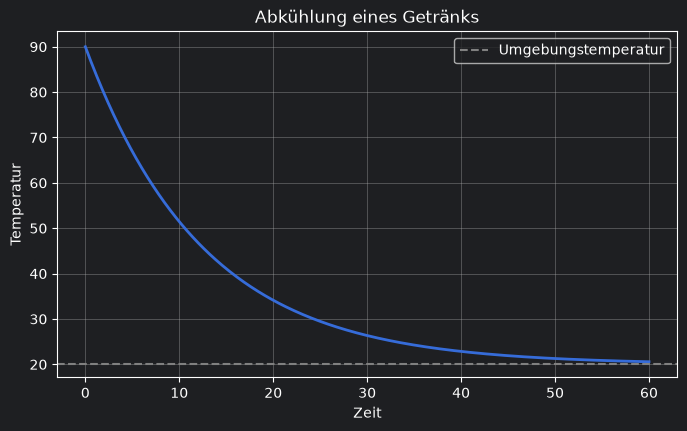

T(30) = 26.35 °C


In [2]:
T_U, T_0, k = 20.0, 90.0, 0.08
t = np.linspace(0, 60, 400)
T = T_U + (T_0 - T_U) * np.exp(-k * t)
plt.plot(t, T, linewidth=2)
plt.axhline(T_U, color='gray', linestyle='--', label='Umgebungstemperatur')
plt.xlabel('Zeit'); plt.ylabel('Temperatur'); plt.legend();
plt.title('Abkühlung eines Getränks'); plt.show()
print(f'T(30) = {T_U + (T_0-T_U)*np.exp(-k*30):.2f} °C')

## 2. Richtungsfeld

Ein Richtungsfeld zeichnet an vielen Punkten $(t,T)$ kleine Pfeile mit der durch die Differentialgleichung vorgeschriebenen Steigung $T'=-k(T-T_U)$. Es zeigt damit nicht eine einzelne Lösung, sondern die mögliche Bewegungsrichtung jeder Lösung.

Oberhalb der Geraden $T=T_U$ zeigen die Pfeile nach unten, darunter nach oben; auf der Geraden selbst sind sie waagerecht. Die eingezeichnete exakte Lösung ist an jedem Punkt tangential zu einem Pfeil. Dadurch wird sichtbar, warum alle Anfangstemperaturen langfristig zur Gleichgewichtstemperatur streben.

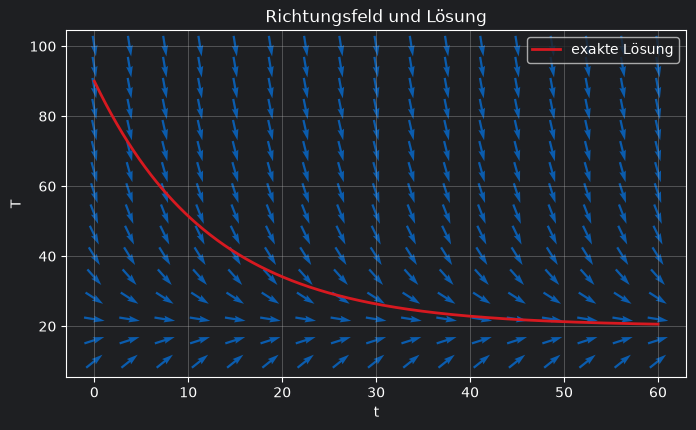

In [3]:
tt = np.linspace(0, 60, 17)
yy = np.linspace(10, 100, 16)
TT, YY = np.meshgrid(tt, yy)
U = np.ones_like(TT)
V = -k * (YY - T_U)
N = np.sqrt(U**2 + V**2)
plt.quiver(TT, YY, U/N, V/N, color='#0b5cad', pivot='mid')
plt.plot(t, T, color='#d71920', linewidth=2, label='exakte Lösung')
plt.xlabel('t'); plt.ylabel('T'); plt.legend(); plt.title('Richtungsfeld und Lösung'); plt.show()

## 3. Euler-Verfahren gegen exakte Lösung

Das explizite Euler-Verfahren ersetzt die Ableitung durch einen Vorwärtsschritt: Aus dem bekannten Wert $T_n$ wird mit der dortigen Steigung der nächste Wert berechnet, $T_{n+1}=T_n+h[-k(T_n-T_U)]$. Es ist somit eine schrittweise lineare Näherung an die Lösungskurve.

Die globale Fehlerordnung ist $O(h)$: Halbiert man die Schrittweite näherungsweise, halbiert sich auch der Fehler. Der Plot vergleicht deshalb mehrere Schrittweiten mit der exakten Exponentialkurve. Große Schritte folgen der richtigen Tendenz, weichen aber sichtbar ab; kleinere Schritte liegen näher an der exakten Lösung.

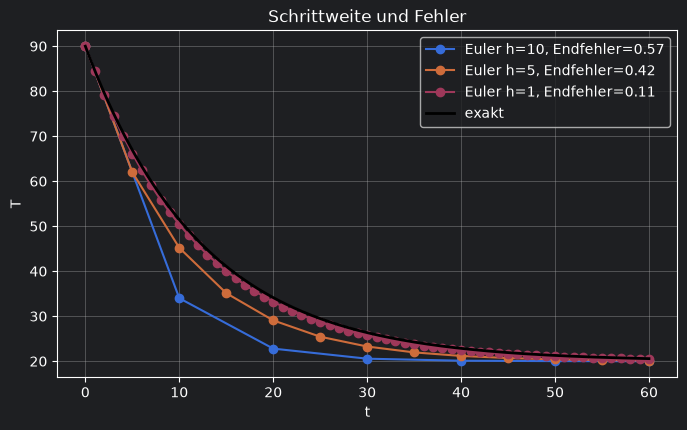

In [4]:
def euler(f, t0, y0, h, steps):
    ts = [t0]; ys = [float(y0)]
    for _ in range(steps):
        ys.append(ys[-1] + h * f(ts[-1], ys[-1]))
        ts.append(ts[-1] + h)
    return np.array(ts), np.array(ys)

for h in (10.0, 5.0, 1.0):
    te, ye = euler(lambda _, temp: -k*(temp-T_U), 0, T_0, h, int(60/h))
    error = abs(ye[-1] - (T_U + (T_0-T_U)*np.exp(-k*60)))
    plt.plot(te, ye, 'o-', label=f'Euler h={h:g}, Endfehler={error:.2f}')
plt.plot(t, T, color='black', linewidth=2, label='exakt')
plt.xlabel('t'); plt.ylabel('T'); plt.legend(); plt.title('Schrittweite und Fehler'); plt.show()

## 4. Variablentrennung

Bei einer separierbaren Differentialgleichung lassen sich alle Terme mit $y$ auf eine und alle Terme mit $x$ auf die andere Seite bringen. Hier gilt $\frac{dy}{y}=x\,dx$. Nach dem Integrieren folgt $\ln|y|=\frac{x^2}{2}+C$ und damit $y=C_1e^{x^2/2}$.

Die Anfangsbedingung $y(0)=1$ bestimmt die Konstante zu $C_1=1$. Die Codezelle leitet die gefundene Funktion ab und überprüft sowohl das Residuum $y'-xy$ als auch den Anfangswert. Ein Residuum von null bestätigt, dass die Funktion die Differentialgleichung tatsächlich löst.

Residuum y' - x y = 0
Anfangswert y(0) = 1


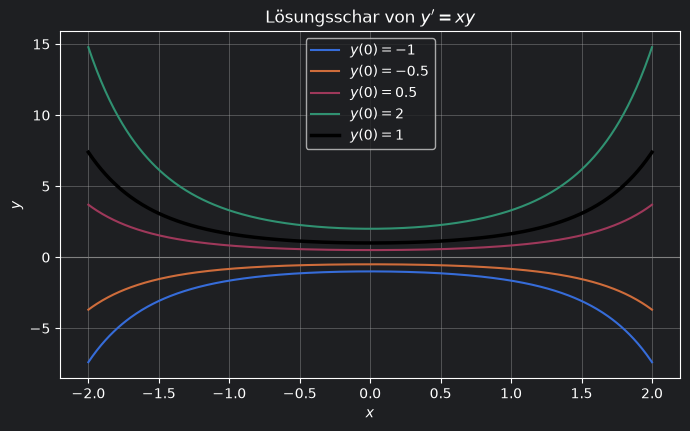

In [7]:
x = sp.symbols('x', real=True)
y = sp.exp(x**2 / 2)
residuum = sp.simplify(sp.diff(y, x) - x*y)
print('Residuum y\' - x y =', residuum)
print('Anfangswert y(0) =', y.subs(x, 0))
assert residuum == 0 and y.subs(x, 0) == 1

x_values = np.linspace(-2, 2, 400)
for initial in (-1.0, -0.5, 0.5, 2.0):
    plt.plot(x_values, initial * np.exp(x_values**2 / 2),
             label=f'$y(0)={initial:g}$')
plt.plot(x_values, np.exp(x_values**2 / 2), color='black', linewidth=2.5,
         label='$y(0)=1$')
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.title("Lösungsschar von $y'=xy$")
plt.legend(); plt.show()

## 5. DGL vom Typ $y'=f(y/x)$

Gleichungen der Form $y'=f(y/x)$ heißen homogen, weil ihr rechter Term nur vom Verhältnis $y/x$ abhängt. Die Substitution $y=vx$ macht dieses Verhältnis zur neuen unbekannten Funktion $v(x)$. Wegen der Produktregel gilt dann $y'=v+xv'$.

Für $y'=1+y/x$ wird daraus $v+xv'=1+v$ und somit $xv'=1$. Jetzt ist die Gleichung separierbar: $dv=dx/x$, also $v=\ln x+C$ für $x>0$. Rücksubstitution liefert $y=x(\ln x+C)$. Die Codezelle setzt diese Lösung wieder ein und prüft, dass das Residuum verschwindet.

Residuum = 0


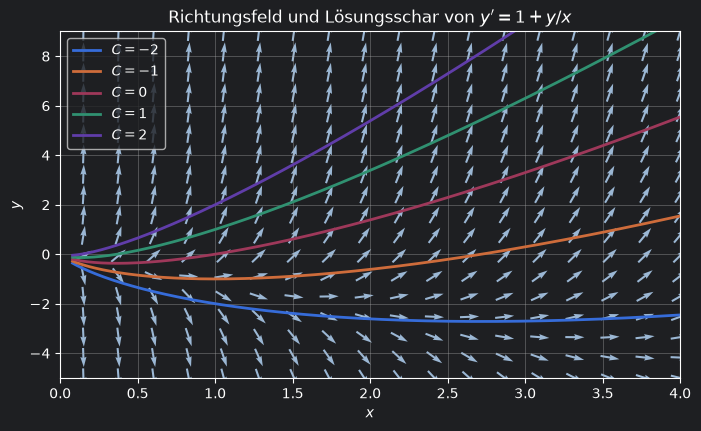

In [8]:
C = sp.symbols('C')
y_hom = x * (sp.log(x) + C)
check = sp.simplify(sp.diff(y_hom, x) - (1 + y_hom/x))
display(y_hom)
print('Residuum =', check)
assert check == 0

x_values = np.linspace(0.08, 4, 400)
X, Y = np.meshgrid(np.linspace(0.15, 4, 18), np.linspace(-5, 9, 18))
U = np.ones_like(X)
V = 1 + Y / X
N = np.hypot(U, V)
plt.quiver(X, Y, U / N, V / N, color='#9bb7d4', pivot='mid')
for constant in (-2.0, -1.0, 0.0, 1.0, 2.0):
    plt.plot(x_values, x_values * (np.log(x_values) + constant), linewidth=2,
             label=f'$C={constant:g}$')
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.xlim(0, 4); plt.ylim(-5, 9)
plt.title("Richtungsfeld und Lösungsschar von $y'=1+y/x$")
plt.legend(); plt.show()